In [280]:
import pandas as pd
import fastf1
import numpy as np

cache_path = '/Users/sukesh/Desktop/Pit/data'
fastf1.Cache.enable_cache(cache_path)

races = [
    (2023, 'Bahrain',     'R'),
    (2023, 'Saudi Arabia','R'),
    (2023, 'Australia',   'R'),
    (2023, 'Azerbaijan',  'R'),
    (2023, 'Monaco',      'R'),
    (2023, 'Spain',       'R'),
    (2023, 'Britain',     'R'),
    (2023, 'Hungary',     'R'),
    (2023, 'Belgium',     'R'),
    (2023, 'Italy',       'R'),
    (2023, 'Japan',       'R'),
    (2023, 'United States', 'R'),
    (2023, 'Canada',      'R'),
    (2023, 'Austria',     'R'),
    (2023, 'Netherlands', 'R'),
    (2023, 'Singapore',   'R')
]

all_laps = []

for year, gp, session_type in races:
    session = fastf1.get_session(year, gp, session_type)
    session.load()

    laps = session.laps.copy()
    laps['will_pit_next_lap'] = laps.groupby(['Driver'])['PitInTime'].shift(-1).notna().astype(int)
    clean_laps = laps.pick_quicklaps()
    clean_laps['LapTimeSeconds'] = clean_laps['LapTime'].dt.total_seconds()
    clean_laps = clean_laps[(clean_laps['LapNumber'] != 1) & (clean_laps['TrackStatus'] == '1')]
    clean_laps['Race'] = gp
    all_laps.append(clean_laps)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
/var/folders/ht/f3q_ryx54sl_yb8g6gt_8fvc0000gn/T/ipykernel_27

In [227]:
combined = pd.concat(all_laps, ignore_index= True)

print(combined.shape)
print(combined['Race'].value_counts())

(13584, 34)
Race
Spain            1081
Canada           1055
Hungary          1041
Austria          1040
United States     922
Monaco            893
Italy             879
Britain           813
Saudi Arabia      810
Bahrain           802
Singapore         797
Azerbaijan        793
Netherlands       739
Australia         732
Japan             656
Belgium           531
Name: count, dtype: int64


In [228]:
combined.sample(5)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,will_pit_next_lap,LapTimeSeconds,Race
5268,0 days 02:12:23.399000,ALO,14,0 days 00:01:31.829000,42.0,2.0,NaT,NaT,0 days 00:00:29.264000,0 days 00:00:37.063000,...,2023-07-09 15:11:52.606,1,6.0,False,,False,True,0,91.829,Britain
4834,0 days 02:29:00.408000,DEV,21,0 days 00:01:19.166000,64.0,3.0,NaT,NaT,0 days 00:00:23.453000,0 days 00:00:31.786000,...,2023-06-04 14:28:41.249,1,14.0,False,,False,True,0,79.166,Spain
9465,0 days 01:39:21.532000,ALB,23,0 days 00:01:42.679000,21.0,2.0,NaT,NaT,0 days 00:00:27.687000,0 days 00:00:41.101000,...,2023-10-22 19:38:41.086,1,12.0,True,TRACK LIMITS AT TURN 20 (NEXT LAP),False,True,0,102.679,United States
8758,0 days 02:30:27.438000,OCO,31,0 days 00:01:38.330000,50.0,3.0,NaT,NaT,0 days 00:00:35.680000,0 days 00:00:43.834000,...,2023-09-24 06:29:50.517,1,10.0,False,,False,True,0,98.330,Japan
121,0 days 02:02:21.125000,PER,11,0 days 00:01:36.820000,36.0,3.0,NaT,NaT,0 days 00:00:30.908000,0 days 00:00:42.254000,...,2023-03-05 16:01:46.154,1,2.0,False,,False,True,0,96.820,Bahrain


In [229]:
combined['will_pit_next_lap'].value_counts()

will_pit_next_lap
0    13217
1      367
Name: count, dtype: int64

In [230]:
combined['LapTimeDelta'] = combined['LapTimeSeconds'] - combined.groupby(['Race','Driver'])['LapTimeSeconds'].transform('mean')

In [231]:
combined.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,will_pit_next_lap,LapTimeSeconds,Race,LapTimeDelta
0,0 days 01:07:31.882000,VER,1,0 days 00:01:38.006000,3.0,1.0,NaT,NaT,0 days 00:00:31.388000,0 days 00:00:42.469000,...,1,1.0,False,,False,True,0,98.006,Bahrain,0.550959
1,0 days 01:09:09.858000,VER,1,0 days 00:01:37.976000,4.0,1.0,NaT,NaT,0 days 00:00:31.271000,0 days 00:00:42.642000,...,1,1.0,False,,False,True,0,97.976,Bahrain,0.520959
2,0 days 01:10:47.893000,VER,1,0 days 00:01:38.035000,5.0,1.0,NaT,NaT,0 days 00:00:31.244000,0 days 00:00:42.724000,...,1,1.0,False,,False,True,0,98.035,Bahrain,0.579959
3,0 days 01:12:25.879000,VER,1,0 days 00:01:37.986000,6.0,1.0,NaT,NaT,0 days 00:00:31.341000,0 days 00:00:42.632000,...,1,1.0,False,,False,True,0,97.986,Bahrain,0.530959
4,0 days 01:14:03.900000,VER,1,0 days 00:01:38.021000,7.0,1.0,NaT,NaT,0 days 00:00:31.290000,0 days 00:00:42.763000,...,1,1.0,False,,False,True,0,98.021,Bahrain,0.565959


In [232]:
combined['TyreLifeSquared'] = combined['TyreLife'] ** 2

In [233]:
combined['LapsRemaining'] = combined.groupby(['Race','Driver'])['LapNumber'].transform('max') - combined['LapNumber']

In [234]:
combined.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Deleted,DeletedReason,FastF1Generated,IsAccurate,will_pit_next_lap,LapTimeSeconds,Race,LapTimeDelta,TyreLifeSquared,LapsRemaining
0,0 days 01:07:31.882000,VER,1,0 days 00:01:38.006000,3.0,1.0,NaT,NaT,0 days 00:00:31.388000,0 days 00:00:42.469000,...,False,,False,True,0,98.006,Bahrain,0.550959,36.0,54.0
1,0 days 01:09:09.858000,VER,1,0 days 00:01:37.976000,4.0,1.0,NaT,NaT,0 days 00:00:31.271000,0 days 00:00:42.642000,...,False,,False,True,0,97.976,Bahrain,0.520959,49.0,53.0
2,0 days 01:10:47.893000,VER,1,0 days 00:01:38.035000,5.0,1.0,NaT,NaT,0 days 00:00:31.244000,0 days 00:00:42.724000,...,False,,False,True,0,98.035,Bahrain,0.579959,64.0,52.0
3,0 days 01:12:25.879000,VER,1,0 days 00:01:37.986000,6.0,1.0,NaT,NaT,0 days 00:00:31.341000,0 days 00:00:42.632000,...,False,,False,True,0,97.986,Bahrain,0.530959,81.0,51.0
4,0 days 01:14:03.900000,VER,1,0 days 00:01:38.021000,7.0,1.0,NaT,NaT,0 days 00:00:31.290000,0 days 00:00:42.763000,...,False,,False,True,0,98.021,Bahrain,0.565959,100.0,50.0


In [235]:
combined[['TyreLife', 'LapTimeDelta', 'TyreLifeSquared', 
          'LapsRemaining', 'will_pit_next_lap']].head(20)

,TyreLife,LapTimeDelta,TyreLifeSquared,LapsRemaining,will_pit_next_lap
0,6.0,0.550959,36.0,54.0,0
1,7.0,0.520959,49.0,53.0,0
2,8.0,0.579959,64.0,52.0,0
3,9.0,0.530959,81.0,51.0,0
4,10.0,0.565959,100.0,50.0,0
5,11.0,0.698959,121.0,49.0,0
6,12.0,0.822959,144.0,48.0,0
7,13.0,0.913959,169.0,47.0,0
8,14.0,1.027959,196.0,46.0,0
9,15.0,1.135959,225.0,45.0,0


In [256]:
null_rows = combined[combined['TyreLifeSquared'].isna()]
null_rows[['Race', 'Driver', 'LapNumber', 'TyreLife', 'TyreLifeSquared']].head(20)

,Race,Driver,LapNumber,TyreLife,TyreLifeSquared


In [255]:
combined = combined.dropna(subset= ['TyreLifeSquared'])

In [ ]:
combined.info()

<class 'fastf1.core.Laps'>
Index: 13549 entries, 0 to 13583
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                13549 non-null  timedelta64[ns]
 1   Driver              13549 non-null  object         
 2   DriverNumber        13549 non-null  object         
 3   LapTime             13549 non-null  timedelta64[ns]
 4   LapNumber           13549 non-null  float64        
 5   Stint               13549 non-null  float64        
 6   PitOutTime          14 non-null     timedelta64[ns]
 7   PitInTime           63 non-null     timedelta64[ns]
 8   Sector1Time         13549 non-null  timedelta64[ns]
 9   Sector2Time         13549 non-null  timedelta64[ns]
 10  Sector3Time         13549 non-null  timedelta64[ns]
 11  Sector1SessionTime  13517 non-null  timedelta64[ns]
 12  Sector2SessionTime  13549 non-null  timedelta64[ns]
 13  Sector3SessionTime  13549 non-null  timedelta64

In [258]:
feature_cols = [
    'TyreLife', 
    'LapTimeDelta', 
    'TyreLifeSquared', 
    'LapsRemaining'
]

test_races = ['Britain', 'Italy']

In [259]:
train = combined[~combined['Race'].isin(test_races)]
test = combined[combined['Race'].isin(test_races)]

X_train = train[feature_cols]
X_test = test[feature_cols]

Y_train = train['will_pit_next_lap']
Y_test = test['will_pit_next_lap']

In [260]:
X_train.shape, X_test.shape

((11857, 4), (1692, 4))

In [261]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

In [262]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [263]:
lr = LogisticRegression(class_weight='balanced', random_state= 42)
lr.fit(X_train_scaled, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [264]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state= 42)
rf.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [265]:
scale_pos_weight = len(Y_train[Y_train==0])/ len(Y_train[Y_train==1])
xgb = XGBClassifier(scale_pos_weight = scale_pos_weight, random_state = 42, eval_metric='logloss')
xgb.fit(X_train, Y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [266]:
print("Train pit stops:", Y_train.sum())
print("Test pit stops:", Y_test.sum())

Train pit stops: 320
Test pit stops: 47


In [267]:
from sklearn.metrics import classification_report, confusion_matrix

lr_preds = lr.predict(X_test_scaled)
print("Logistic Regression")
print(classification_report(Y_test, lr_preds))

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.66      0.79      1645
           1       0.07      0.85      0.12        47

    accuracy                           0.66      1692
   macro avg       0.53      0.75      0.46      1692
weighted avg       0.97      0.66      0.77      1692



In [268]:
rf_preds = rf.predict(X_test)
print("Random Forest")
print(classification_report(Y_test, rf_preds))

Random Forest
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1645
           1       0.00      0.00      0.00        47

    accuracy                           0.97      1692
   macro avg       0.49      0.50      0.49      1692
weighted avg       0.95      0.97      0.96      1692



In [269]:
xgb_preds = xgb.predict(X_test)
print("XGBoost")
print(classification_report(Y_test, xgb_preds))

XGBoost
              precision    recall  f1-score   support

           0       0.97      0.93      0.95      1645
           1       0.06      0.15      0.08        47

    accuracy                           0.91      1692
   macro avg       0.52      0.54      0.52      1692
weighted avg       0.95      0.91      0.93      1692



In [270]:
xgb_probs = xgb.predict_proba(X_test)[:, 1]

In [272]:
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:
    preds = (xgb_probs >= threshold).astype(int)
    from sklearn.metrics import f1_score, precision_score, recall_score
    print(f"Threshold {threshold:.1f} → "
          f"Precision: {precision_score(Y_test, preds, zero_division=0):.2f} "
          f"Recall: {recall_score(Y_test, preds):.2f} "
          f"F1: {f1_score(Y_test, preds):.2f}")

Threshold 0.5 → Precision: 0.06 Recall: 0.15 F1: 0.08
Threshold 0.4 → Precision: 0.07 Recall: 0.21 F1: 0.10
Threshold 0.3 → Precision: 0.06 Recall: 0.28 F1: 0.10
Threshold 0.2 → Precision: 0.07 Recall: 0.43 F1: 0.12
Threshold 0.1 → Precision: 0.07 Recall: 0.62 F1: 0.12


In [275]:
import shap

In [277]:
explainer = shap.LinearExplainer(lr, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

Background dataset has 11857 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=11857 when initializing the masker.


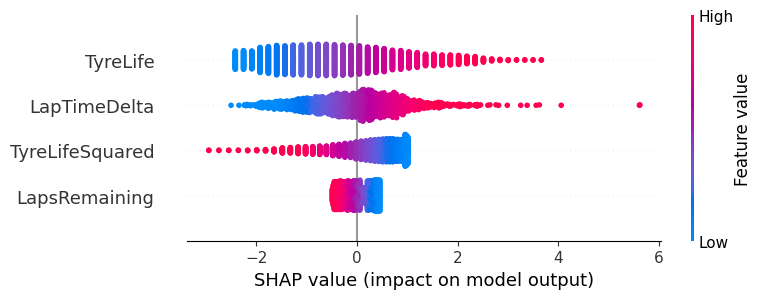

In [278]:
shap.summary_plot(shap_values, X_test, feature_names= feature_cols)

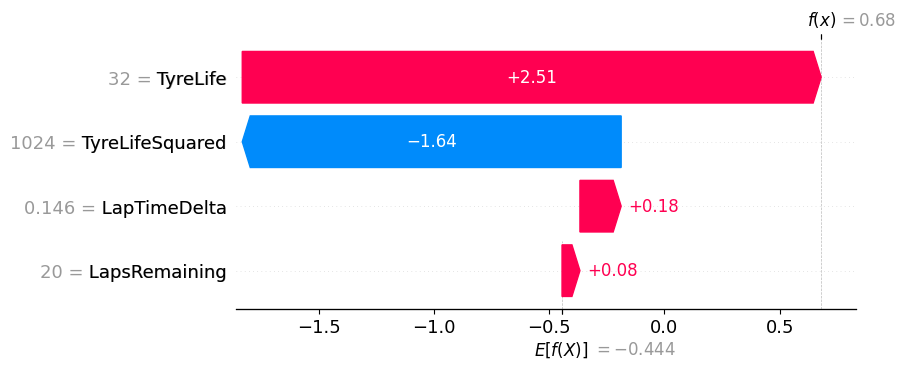

In [289]:
correct_pit_idx = np.where((lr.predict(X_test_scaled) == 1) & 
                            (Y_test.values == 1))[0][0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[correct_pit_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[correct_pit_idx],
        feature_names=feature_cols
    )
)